In [ ]:
# U.S. Macroeconomic & Labor Market Analysis

## Project Overview

# This project analyzes U.S. macroeconomic conditions using GDP, inflation,
# and unemployment data. The goal is to identify long-term economic trends
# and examine relationships among major economic indicators using exploratory
# data analysis, visualization, SQL, and regression modeling.

## Research Questions

# 1. How have U.S. GDP growth, inflation, and unemployment changed over time?
# 2. What relationship exists between GDP growth and unemployment?
# 3. What relationship exists between inflation and unemployment?
# 4. Which periods experienced unusually large economic changes?
# 5. Are the observed relationships statistically significant?

## Tools & Technologies

# - Python
# - Pandas
# - NumPy
# - Matplotlib
# - SQL
# - Statsmodels
# - Google Colab

## Data Source

# Economic data is sourced from the Federal Reserve Bank of St. Louis
# FRED database.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import sqlite3

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
# Load the three FRED datasets

gdp = pd.read_csv("/content/GDPC1.csv")
cpi = pd.read_csv("/content/CPIAUCSL.csv")
unemployment = pd.read_csv("/content/UNRATE.csv")

print("GDP DATA")
display(gdp.head())

print("\nCPI DATA")
display(cpi.head())

print("\nUNEMPLOYMENT DATA")
display(unemployment.head())

GDP DATA


,observation_date,GDPC1
0,1947-01-01,"2,182.68"
1,1947-04-01,"2,176.89"
2,1947-07-01,"2,172.43"
3,1947-10-01,"2,206.45"
4,1948-01-01,"2,239.68"



CPI DATA


,observation_date,CPIAUCSL
0,1947-01-01,21.48
1,1947-02-01,21.62
2,1947-03-01,22.00
3,1947-04-01,22.00
4,1947-05-01,21.95



UNEMPLOYMENT DATA


,observation_date,UNRATE
0,1948-01-01,3.40
1,1948-02-01,3.80
2,1948-03-01,4.00
3,1948-04-01,3.90
4,1948-05-01,3.50


In [5]:
# Inspect dataset structure, size, and missing values

datasets = {
    "GDP": gdp,
    "CPI": cpi,
    "Unemployment": unemployment
}

for name, df in datasets.items():
    print(f"\n{name} DATASET")
    print("-" * 40)
    print(f"Rows: {df.shape[0]}")
    print(f"Columns: {df.shape[1]}")
    print(f"Date range: {df['observation_date'].min()} to {df['observation_date'].max()}")
    print(f"Missing values:\n{df.isnull().sum()}")


GDP DATASET
----------------------------------------
Rows: 318
Columns: 2
Date range: 1947-01-01 to 2026-04-01
Missing values:
observation_date    0
GDPC1               0
dtype: int64

CPI DATASET
----------------------------------------
Rows: 956
Columns: 2
Date range: 1947-01-01 to 2026-08-01
Missing values:
observation_date    0
CPIAUCSL            1
dtype: int64

Unemployment DATASET
----------------------------------------
Rows: 944
Columns: 2
Date range: 1948-01-01 to 2026-08-01
Missing values:
observation_date    0
UNRATE              1
dtype: int64


In [6]:
# Convert dates to datetime format

gdp["observation_date"] = pd.to_datetime(gdp["observation_date"])
cpi["observation_date"] = pd.to_datetime(cpi["observation_date"])
unemployment["observation_date"] = pd.to_datetime(unemployment["observation_date"])

# Rename columns for readability

gdp = gdp.rename(columns={
    "observation_date": "Date",
    "GDPC1": "Real_GDP"
})

cpi = cpi.rename(columns={
    "observation_date": "Date",
    "CPIAUCSL": "CPI"
})

unemployment = unemployment.rename(columns={
    "observation_date": "Date",
    "UNRATE": "Unemployment_Rate"
})

# Display cleaned column names and first five observations

print("GDP")
display(gdp.head())

print("\nCPI")
display(cpi.head())

print("\nUNEMPLOYMENT")
display(unemployment.head())

GDP


,Date,Real_GDP
0,1947-01-01,"2,182.68"
1,1947-04-01,"2,176.89"
2,1947-07-01,"2,172.43"
3,1947-10-01,"2,206.45"
4,1948-01-01,"2,239.68"



CPI


,Date,CPI
0,1947-01-01,21.48
1,1947-02-01,21.62
2,1947-03-01,22.00
3,1947-04-01,22.00
4,1947-05-01,21.95



UNEMPLOYMENT


,Date,Unemployment_Rate
0,1948-01-01,3.40
1,1948-02-01,3.80
2,1948-03-01,4.00
3,1948-04-01,3.90
4,1948-05-01,3.50


In [7]:
# Identify missing observations

print("Missing CPI observations:")
display(cpi[cpi["CPI"].isna()])

print("\nMissing unemployment observations:")
display(unemployment[unemployment["Unemployment_Rate"].isna()])

Missing CPI observations:


,Date,CPI
945,2025-10-01,NaN



Missing unemployment observations:


,Date,Unemployment_Rate
933,2025-10-01,NaN


In [8]:
start_date = "2000-01-01"
end_date = "2024-12-31"

gdp_analysis = gdp[
    (gdp["Date"] >= start_date) &
    (gdp["Date"] <= end_date)
].copy()

cpi_analysis = cpi[
    (cpi["Date"] >= start_date) &
    (cpi["Date"] <= end_date)
].copy()

unemployment_analysis = unemployment[
    (unemployment["Date"] >= start_date) &
    (unemployment["Date"] <= end_date)
].copy()

print("Analysis period: 2000–2024")
print(f"GDP observations: {len(gdp_analysis)}")
print(f"CPI observations: {len(cpi_analysis)}")
print(f"Unemployment observations: {len(unemployment_analysis)}")

print("\nMissing values:")
print(f"GDP: {gdp_analysis['Real_GDP'].isna().sum()}")
print(f"CPI: {cpi_analysis['CPI'].isna().sum()}")
print(f"Unemployment: {unemployment_analysis['Unemployment_Rate'].isna().sum()}")

Analysis period: 2000–2024
GDP observations: 100
CPI observations: 300
Unemployment observations: 300

Missing values:
GDP: 0
CPI: 0
Unemployment: 0


In [9]:
# Convert monthly CPI and unemployment data to quarterly averages

cpi_quarterly = (
    cpi_analysis
    .set_index("Date")
    .resample("QS")["CPI"]
    .mean()
    .reset_index()
)

unemployment_quarterly = (
    unemployment_analysis
    .set_index("Date")
    .resample("QS")["Unemployment_Rate"]
    .mean()
    .reset_index()
)

print("Quarterly CPI:")
display(cpi_quarterly.head())

print("\nQuarterly Unemployment:")
display(unemployment_quarterly.head())

Quarterly CPI:


,Date,CPI
0,2000-01-01,170.10
1,2000-04-01,171.43
2,2000-07-01,173.00
3,2000-10-01,174.23
4,2001-01-01,175.90



Quarterly Unemployment:


,Date,Unemployment_Rate
0,2000-01-01,4.03
1,2000-04-01,3.93
2,2000-07-01,4.00
3,2000-10-01,3.90
4,2001-01-01,4.23


In [10]:
# Merge GDP, CPI, and unemployment into one quarterly dataset

macro = (
    gdp_analysis
    .merge(cpi_quarterly, on="Date", how="inner")
    .merge(unemployment_quarterly, on="Date", how="inner")
)

# Add year and quarter identifiers

macro["Year"] = macro["Date"].dt.year
macro["Quarter"] = "Q" + macro["Date"].dt.quarter.astype(str)

# Reorder columns

macro = macro[
    [
        "Date",
        "Year",
        "Quarter",
        "Real_GDP",
        "CPI",
        "Unemployment_Rate"
    ]
]

print(f"Master dataset contains {len(macro)} quarterly observations.")

display(macro.head(10))

Master dataset contains 100 quarterly observations.


,Date,Year,Quarter,Real_GDP,CPI,Unemployment_Rate
0,2000-01-01,2000,Q1,"13,878.15",170.10,4.03
1,2000-04-01,2000,Q2,"14,130.91",171.43,3.93
2,2000-07-01,2000,Q3,"14,145.31",173.00,4.00
3,2000-10-01,2000,Q4,"14,229.76",174.23,3.90
4,2001-01-01,2001,Q1,"14,183.12",175.90,4.23
5,2001-04-01,2001,Q2,"14,271.69",177.13,4.40
6,2001-07-01,2001,Q3,"14,214.52",177.63,4.83
7,2001-10-01,2001,Q4,"14,253.57",177.50,5.50
8,2002-01-01,2002,Q1,"14,372.78",178.07,5.70
9,2002-04-01,2002,Q2,"14,460.85",179.47,5.83


In [11]:
# Calculate economic growth and inflation rates

# Annualized quarter-over-quarter real GDP growth
macro["GDP_Growth"] = (
    ((macro["Real_GDP"] / macro["Real_GDP"].shift(1)) ** 4 - 1) * 100
)

# Year-over-year inflation using quarterly average CPI
macro["Inflation_Rate"] = (
    macro["CPI"].pct_change(periods=4, fill_method=None) * 100
)

# Reorder columns
macro = macro[
    [
        "Date",
        "Year",
        "Quarter",
        "Real_GDP",
        "GDP_Growth",
        "CPI",
        "Inflation_Rate",
        "Unemployment_Rate"
    ]
]

display(macro.head(10))

,Date,Year,Quarter,Real_GDP,GDP_Growth,CPI,Inflation_Rate,Unemployment_Rate
0,2000-01-01,2000,Q1,"13,878.15",NaN,170.10,NaN,4.03
1,2000-04-01,2000,Q2,"14,130.91",7.49,171.43,NaN,3.93
2,2000-07-01,2000,Q3,"14,145.31",0.41,173.00,NaN,4.00
3,2000-10-01,2000,Q4,"14,229.76",2.41,174.23,NaN,3.90
4,2001-01-01,2001,Q1,"14,183.12",-1.30,175.90,3.41,4.23
5,2001-04-01,2001,Q2,"14,271.69",2.52,177.13,3.32,4.40
6,2001-07-01,2001,Q3,"14,214.52",-1.59,177.63,2.68,4.83
7,2001-10-01,2001,Q4,"14,253.57",1.10,177.50,1.87,5.50
8,2002-01-01,2002,Q1,"14,372.78",3.39,178.07,1.23,5.70
9,2002-04-01,2002,Q2,"14,460.85",2.47,179.47,1.32,5.83


In [12]:
# Create final modeling dataset by removing rows
# without calculated growth/inflation values

model_data = macro.dropna(
    subset=["GDP_Growth", "Inflation_Rate"]
).copy()

print("FINAL MODELING DATASET")
print("-" * 40)
print(f"Observations: {len(model_data)}")
print(f"Start date: {model_data['Date'].min().date()}")
print(f"End date: {model_data['Date'].max().date()}")
print(f"Missing values: {model_data.isnull().sum().sum()}")

display(model_data.head())

FINAL MODELING DATASET
----------------------------------------
Observations: 96
Start date: 2001-01-01
End date: 2024-10-01
Missing values: 0


,Date,Year,Quarter,Real_GDP,GDP_Growth,CPI,Inflation_Rate,Unemployment_Rate
4,2001-01-01,2001,Q1,"14,183.12",-1.30,175.90,3.41,4.23
5,2001-04-01,2001,Q2,"14,271.69",2.52,177.13,3.32,4.40
6,2001-07-01,2001,Q3,"14,214.52",-1.59,177.63,2.68,4.83
7,2001-10-01,2001,Q4,"14,253.57",1.10,177.50,1.87,5.50
8,2002-01-01,2002,Q1,"14,372.78",3.39,178.07,1.23,5.70


In [13]:
# Identify notable economic periods

print("HIGHEST GDP GROWTH")
display(
    model_data.nlargest(
        5, "GDP_Growth"
    )[["Date", "GDP_Growth", "Unemployment_Rate"]]
)

print("\nLOWEST GDP GROWTH")
display(
    model_data.nsmallest(
        5, "GDP_Growth"
    )[["Date", "GDP_Growth", "Unemployment_Rate"]]
)

print("\nHIGHEST INFLATION")
display(
    model_data.nlargest(
        5, "Inflation_Rate"
    )[["Date", "Inflation_Rate", "Unemployment_Rate"]]
)

print("\nHIGHEST UNEMPLOYMENT")
display(
    model_data.nlargest(
        5, "Unemployment_Rate"
    )[["Date", "Unemployment_Rate", "GDP_Growth"]]
)

HIGHEST GDP GROWTH


,Date,GDP_Growth,Unemployment_Rate
82,2020-07-01,34.86,8.80
87,2021-10-01,7.04,4.17
85,2021-04-01,6.98,5.93
14,2003-07-01,6.82,6.13
84,2021-01-01,5.70,6.23



LOWEST GDP GROWTH


,Date,GDP_Growth,Unemployment_Rate
81,2020-04-01,-27.98,13.00
35,2008-10-01,-8.47,6.87
80,2020-01-01,-5.16,3.83
36,2009-01-01,-4.46,8.27
34,2008-07-01,-2.08,6.00



HIGHEST INFLATION


,Date,Inflation_Rate,Unemployment_Rate
89,2022-04-01,8.58,3.63
90,2022-07-01,8.29,3.53
88,2022-01-01,8.02,3.87
91,2022-10-01,7.09,3.57
87,2021-10-01,6.77,4.17



HIGHEST UNEMPLOYMENT


,Date,Unemployment_Rate,GDP_Growth
81,2020-04-01,13.00,-27.98
39,2009-10-01,9.93,4.39
40,2010-01-01,9.83,1.95
38,2009-07-01,9.63,1.41
41,2010-04-01,9.63,3.93


In [14]:
# Generate descriptive statistics for key economic indicators

summary_stats = model_data[
    ["GDP_Growth", "Inflation_Rate", "Unemployment_Rate"]
].describe().round(2)

print("DESCRIPTIVE STATISTICS")
display(summary_stats)

DESCRIPTIVE STATISTICS


,GDP_Growth,Inflation_Rate,Unemployment_Rate
count,96.00,96.00,96.00
mean,2.26,2.55,5.77
std,5.15,1.76,1.96
min,-27.98,-1.61,3.53
25%,1.18,1.59,4.31
50%,2.51,2.18,5.20
75%,3.49,3.33,6.69
max,34.86,8.58,13.00


In [15]:
# Calculate correlations among key economic indicators

correlation_matrix = model_data[
    ["GDP_Growth", "Inflation_Rate", "Unemployment_Rate"]
].corr().round(3)

print("CORRELATION MATRIX")
display(correlation_matrix)

CORRELATION MATRIX


,GDP_Growth,Inflation_Rate,Unemployment_Rate
GDP_Growth,1.00,0.06,-0.16
Inflation_Rate,0.06,1.00,-0.43
Unemployment_Rate,-0.16,-0.43,1.00


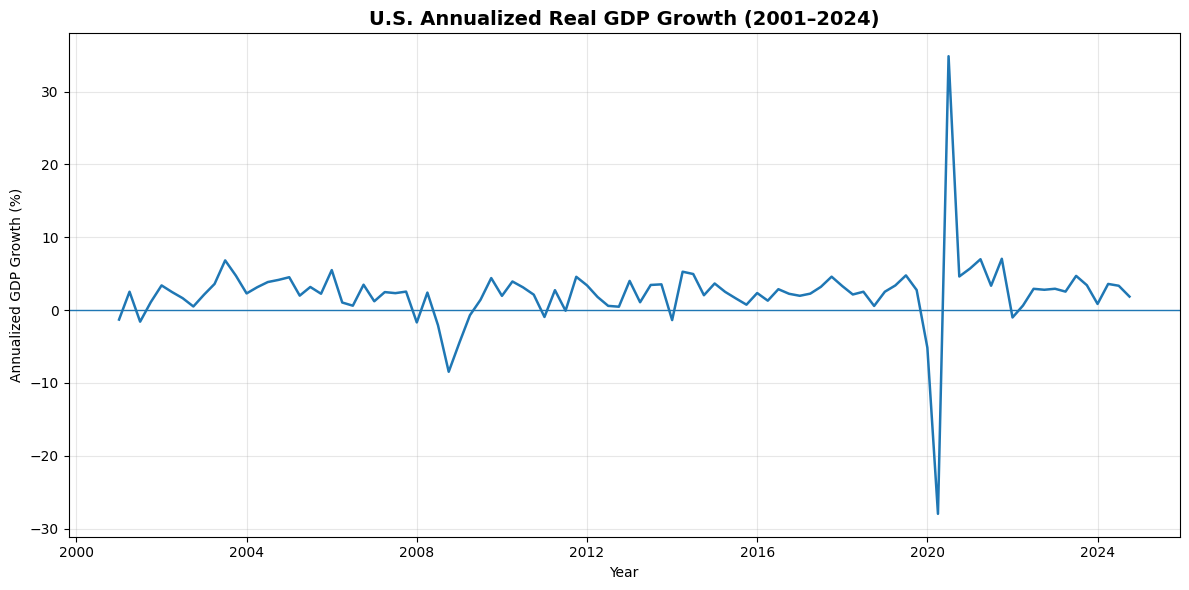

In [16]:
# Visualize real GDP growth over time

plt.figure(figsize=(12, 6))

plt.plot(
    model_data["Date"],
    model_data["GDP_Growth"],
    linewidth=1.8
)

plt.axhline(0, linewidth=1)

plt.title(
    "U.S. Annualized Real GDP Growth (2001–2024)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Annualized GDP Growth (%)")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

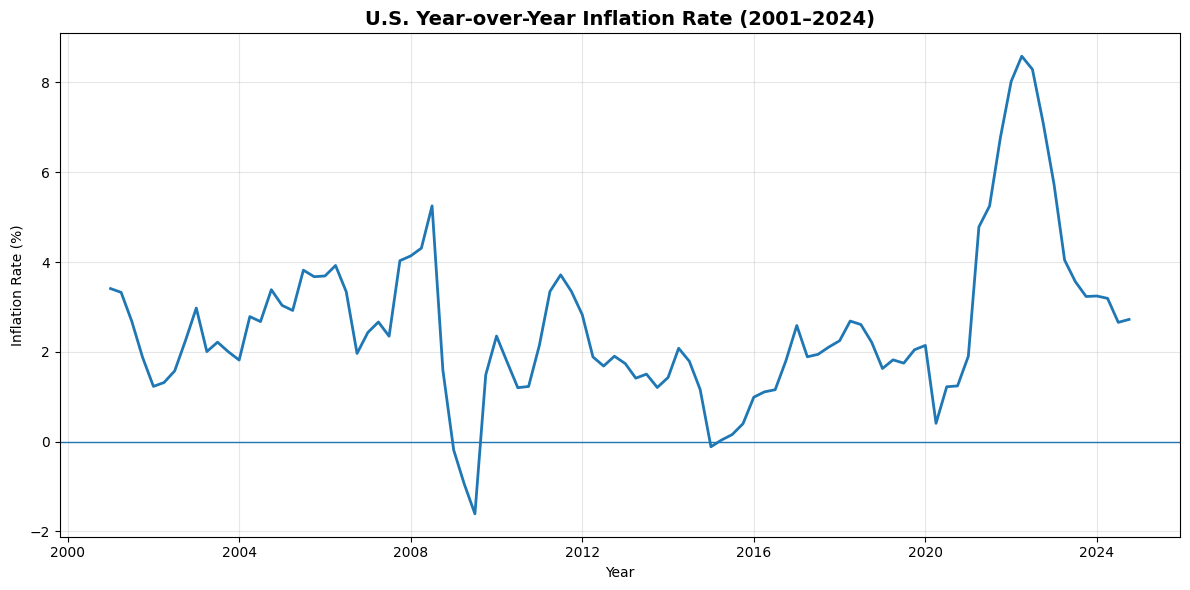

In [17]:
# Visualize U.S. inflation over time

plt.figure(figsize=(12, 6))

plt.plot(
    model_data["Date"],
    model_data["Inflation_Rate"],
    linewidth=2
)

plt.axhline(0, linewidth=1)

plt.title(
    "U.S. Year-over-Year Inflation Rate (2001–2024)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Inflation Rate (%)")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

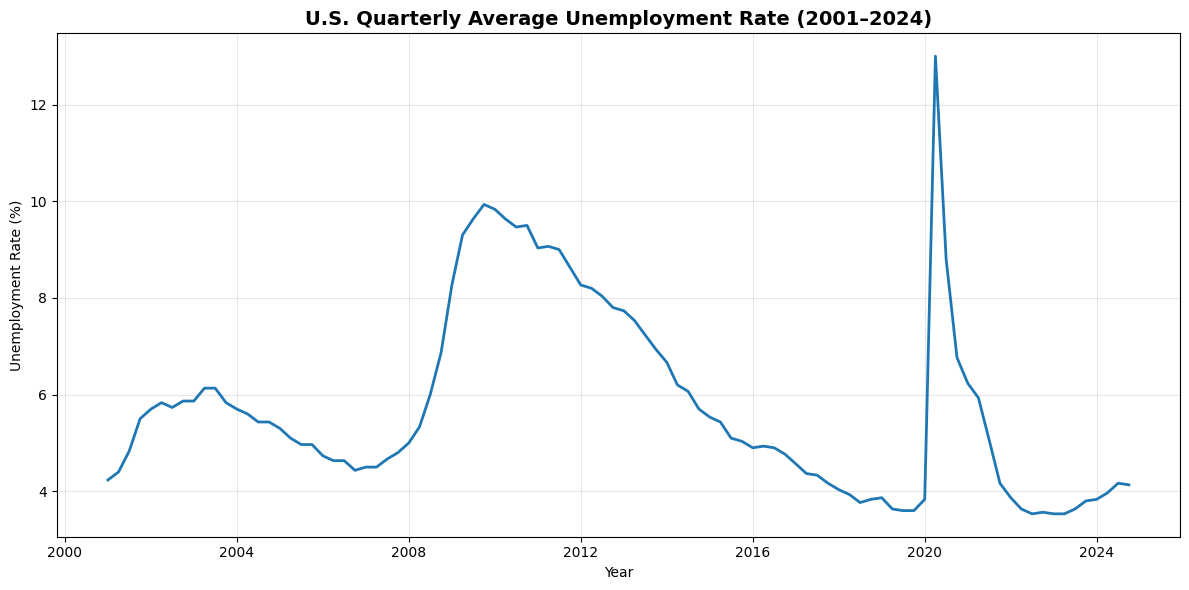

In [18]:
# Visualize U.S. unemployment over time

plt.figure(figsize=(12, 6))

plt.plot(
    model_data["Date"],
    model_data["Unemployment_Rate"],
    linewidth=2
)

plt.title(
    "U.S. Quarterly Average Unemployment Rate (2001–2024)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

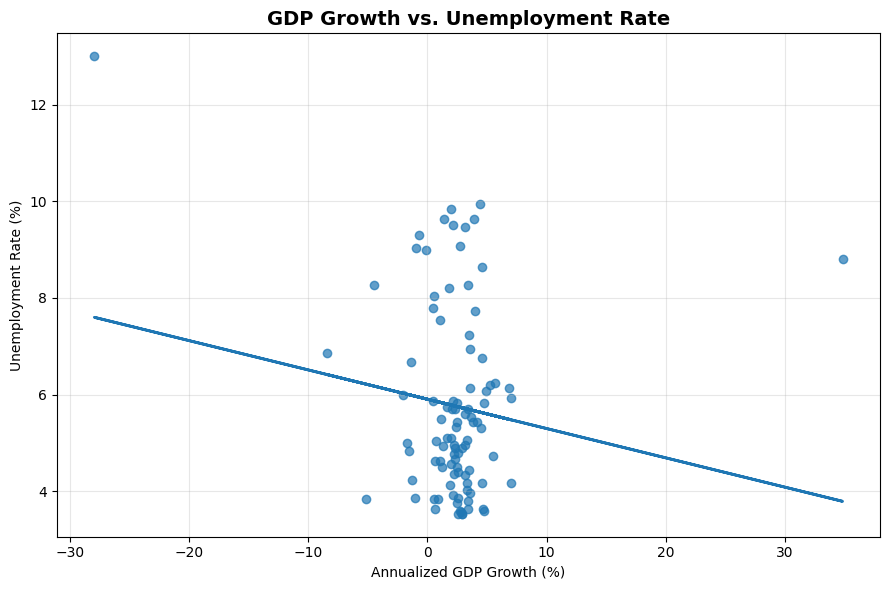

In [19]:
# Examine the relationship between GDP growth and unemployment

x = model_data["GDP_Growth"]
y = model_data["Unemployment_Rate"]

# Calculate linear trend line
slope, intercept = np.polyfit(x, y, 1)

plt.figure(figsize=(9, 6))

plt.scatter(x, y, alpha=0.7)

plt.plot(
    x,
    slope * x + intercept,
    linewidth=2
)

plt.title(
    "GDP Growth vs. Unemployment Rate",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Annualized GDP Growth (%)")
plt.ylabel("Unemployment Rate (%)")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [20]:
# Regression analysis: GDP growth and unemployment

# Dependent variable
y = model_data["Unemployment_Rate"]

# Independent variable
X = model_data[["GDP_Growth"]]

# Add intercept
X = sm.add_constant(X)

# Fit ordinary least squares regression
gdp_unemployment_model = sm.OLS(y, X).fit()

# Display regression results
print(gdp_unemployment_model.summary())

                            OLS Regression Results                            
Dep. Variable:      Unemployment_Rate   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     2.435
Date:                Wed, 16 Sep 2026   Prob (F-statistic):              0.122
Time:                        21:12:33   Log-Likelihood:                -199.24
No. Observations:                  96   AIC:                             402.5
Df Residuals:                      94   BIC:                             407.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.9039      0.217     27.165      0.0

In [21]:
# Regression analysis: inflation and unemployment

# Dependent variable
y = model_data["Unemployment_Rate"]

# Independent variable
X = model_data[["Inflation_Rate"]]

# Add intercept
X = sm.add_constant(X)

# Fit ordinary least squares regression
inflation_unemployment_model = sm.OLS(y, X).fit()

# Display regression results
print(inflation_unemployment_model.summary())

                            OLS Regression Results                            
Dep. Variable:      Unemployment_Rate   R-squared:                       0.190
Model:                            OLS   Adj. R-squared:                  0.181
Method:                 Least Squares   F-statistic:                     22.00
Date:                Wed, 16 Sep 2026   Prob (F-statistic):           9.23e-06
Time:                        21:13:11   Log-Likelihood:                -190.37
No. Observations:                  96   AIC:                             384.7
Df Residuals:                      94   BIC:                             389.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              7.0018      0.320     21.

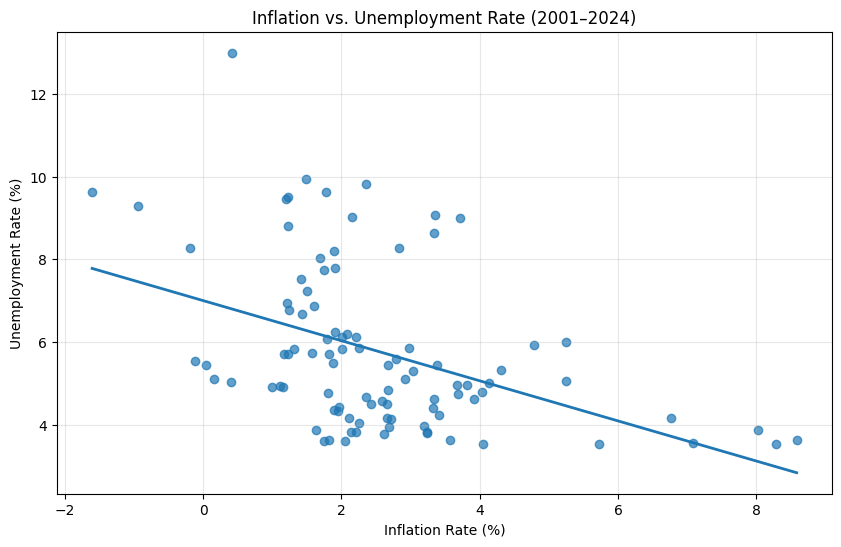

In [22]:
# Visualize relationship between inflation and unemployment

plt.figure(figsize=(10, 6))

plt.scatter(
    model_data["Inflation_Rate"],
    model_data["Unemployment_Rate"],
    alpha=0.7
)

# Regression line
x = model_data["Inflation_Rate"]
y_pred = inflation_unemployment_model.predict(
    sm.add_constant(model_data[["Inflation_Rate"]])
)

# Sort values so regression line plots cleanly
sorted_idx = x.argsort()

plt.plot(
    x.iloc[sorted_idx],
    y_pred.iloc[sorted_idx],
    linewidth=2
)

plt.title("Inflation vs. Unemployment Rate (2001–2024)")
plt.xlabel("Inflation Rate (%)")
plt.ylabel("Unemployment Rate (%)")
plt.grid(alpha=0.3)

plt.show()

In [23]:
# Create an in-memory SQLite database

conn = sqlite3.connect(":memory:")

# Store the cleaned economic dataset as a SQL table
model_data.to_sql(
    "economic_data",
    conn,
    if_exists="replace",
    index=False
)

print("SQL database created successfully.")

# Verify number of records
query = """
SELECT COUNT(*) AS total_records
FROM economic_data;
"""

pd.read_sql_query(query, conn)

SQL database created successfully.


,total_records
0,96


In [24]:
# SQL analysis: annual economic summary

query = """
SELECT
    Year,
    ROUND(AVG(GDP_Growth), 2) AS Avg_GDP_Growth,
    ROUND(AVG(Inflation_Rate), 2) AS Avg_Inflation_Rate,
    ROUND(AVG(Unemployment_Rate), 2) AS Avg_Unemployment_Rate
FROM economic_data
GROUP BY Year
ORDER BY Year;
"""

annual_summary = pd.read_sql_query(query, conn)

print("ANNUAL ECONOMIC SUMMARY")
display(annual_summary)

ANNUAL ECONOMIC SUMMARY


,Year,Avg_GDP_Growth,Avg_Inflation_Rate,Avg_Unemployment_Rate
0,2001,0.18,2.82,4.74
1,2002,2.00,1.59,5.78
2,2003,4.31,2.30,5.99
3,2004,3.35,2.67,5.54
4,2005,2.98,3.36,5.08
5,2006,2.65,3.23,4.61
6,2007,2.13,2.87,4.62
7,2008,-2.46,3.82,5.80
8,2009,0.16,-0.31,9.28
9,2010,2.78,1.64,9.61


In [25]:
# SQL analysis: identify extreme economic periods

# Lowest GDP growth quarters
query = """
SELECT
    Date,
    Year,
    Quarter,
    ROUND(GDP_Growth, 2) AS GDP_Growth,
    ROUND(Inflation_Rate, 2) AS Inflation_Rate,
    ROUND(Unemployment_Rate, 2) AS Unemployment_Rate
FROM economic_data
ORDER BY GDP_Growth ASC
LIMIT 5;
"""

lowest_growth_sql = pd.read_sql_query(query, conn)

print("5 QUARTERS WITH LOWEST GDP GROWTH")
display(lowest_growth_sql)


# Highest inflation quarters
query = """
SELECT
    Date,
    Year,
    Quarter,
    ROUND(Inflation_Rate, 2) AS Inflation_Rate,
    ROUND(GDP_Growth, 2) AS GDP_Growth,
    ROUND(Unemployment_Rate, 2) AS Unemployment_Rate
FROM economic_data
ORDER BY Inflation_Rate DESC
LIMIT 5;
"""

highest_inflation_sql = pd.read_sql_query(query, conn)

print("\n5 QUARTERS WITH HIGHEST INFLATION")
display(highest_inflation_sql)


# Highest unemployment quarters
query = """
SELECT
    Date,
    Year,
    Quarter,
    ROUND(Unemployment_Rate, 2) AS Unemployment_Rate,
    ROUND(GDP_Growth, 2) AS GDP_Growth,
    ROUND(Inflation_Rate, 2) AS Inflation_Rate
FROM economic_data
ORDER BY Unemployment_Rate DESC
LIMIT 5;
"""

highest_unemployment_sql = pd.read_sql_query(query, conn)

print("\n5 QUARTERS WITH HIGHEST UNEMPLOYMENT")
display(highest_unemployment_sql)

5 QUARTERS WITH LOWEST GDP GROWTH


,Date,Year,Quarter,GDP_Growth,Inflation_Rate,Unemployment_Rate
0,2020-04-01 00:00:00,2020,Q2,-27.98,0.41,13.00
1,2008-10-01 00:00:00,2008,Q4,-8.47,1.60,6.87
2,2020-01-01 00:00:00,2020,Q1,-5.16,2.14,3.83
3,2009-01-01 00:00:00,2009,Q1,-4.46,-0.18,8.27
4,2008-07-01 00:00:00,2008,Q3,-2.08,5.25,6.00



5 QUARTERS WITH HIGHEST INFLATION


,Date,Year,Quarter,Inflation_Rate,GDP_Growth,Unemployment_Rate
0,2022-04-01 00:00:00,2022,Q2,8.58,0.63,3.63
1,2022-07-01 00:00:00,2022,Q3,8.29,2.92,3.53
2,2022-01-01 00:00:00,2022,Q1,8.02,-1.02,3.87
3,2022-10-01 00:00:00,2022,Q4,7.09,2.79,3.57
4,2021-10-01 00:00:00,2021,Q4,6.77,7.04,4.17



5 QUARTERS WITH HIGHEST UNEMPLOYMENT


,Date,Year,Quarter,Unemployment_Rate,GDP_Growth,Inflation_Rate
0,2020-04-01 00:00:00,2020,Q2,13.00,-27.98,0.41
1,2009-10-01 00:00:00,2009,Q4,9.93,4.39,1.49
2,2010-01-01 00:00:00,2010,Q1,9.83,1.95,2.35
3,2009-07-01 00:00:00,2009,Q3,9.63,1.41,-1.61
4,2010-04-01 00:00:00,2010,Q2,9.63,3.93,1.78


In [26]:
# SQL analysis: classify quarters by economic conditions

query = """
SELECT
    CASE
        WHEN GDP_Growth < 0 THEN 'GDP Contraction'
        ELSE 'GDP Expansion'
    END AS Economic_Condition,

    COUNT(*) AS Number_of_Quarters,

    ROUND(AVG(GDP_Growth), 2) AS Avg_GDP_Growth,
    ROUND(AVG(Inflation_Rate), 2) AS Avg_Inflation,
    ROUND(AVG(Unemployment_Rate), 2) AS Avg_Unemployment

FROM economic_data

GROUP BY
    CASE
        WHEN GDP_Growth < 0 THEN 'GDP Contraction'
        ELSE 'GDP Expansion'
    END

ORDER BY Avg_GDP_Growth;
"""

economic_conditions = pd.read_sql_query(query, conn)

print("ECONOMIC CONDITIONS: CONTRACTION VS. EXPANSION")
display(economic_conditions)

ECONOMIC CONDITIONS: CONTRACTION VS. EXPANSION


,Economic_Condition,Number_of_Quarters,Avg_GDP_Growth,Avg_Inflation,Avg_Unemployment
0,GDP Contraction,13,-4.38,2.60,6.92
1,GDP Expansion,83,3.30,2.54,5.59


In [27]:
# SQL analysis: compare high-inflation and lower-inflation periods

query = """
SELECT
    CASE
        WHEN Inflation_Rate >= 5 THEN 'High Inflation (5%+)'
        ELSE 'Below 5% Inflation'
    END AS Inflation_Environment,

    COUNT(*) AS Number_of_Quarters,

    ROUND(AVG(Inflation_Rate), 2) AS Avg_Inflation,
    ROUND(AVG(GDP_Growth), 2) AS Avg_GDP_Growth,
    ROUND(AVG(Unemployment_Rate), 2) AS Avg_Unemployment

FROM economic_data

GROUP BY
    CASE
        WHEN Inflation_Rate >= 5 THEN 'High Inflation (5%+)'
        ELSE 'Below 5% Inflation'
    END

ORDER BY Avg_Inflation DESC;
"""

inflation_conditions = pd.read_sql_query(query, conn)

print("HIGH-INFLATION VS. LOWER-INFLATION PERIODS")
display(inflation_conditions)

HIGH-INFLATION VS. LOWER-INFLATION PERIODS


,Inflation_Environment,Number_of_Quarters,Avg_Inflation,Avg_GDP_Growth,Avg_Unemployment
0,High Inflation (5%+),8,6.87,2.07,4.17
1,Below 5% Inflation,88,2.15,2.28,5.91


In [29]:
## Key Findings

# This analysis examined 96 quarterly observations of U.S. real GDP growth, inflation, and unemployment from 2001–2024 using Federal Reserve Economic Data (FRED).

### Economic Trends
# - The largest GDP contraction occurred in 2020 Q2, when annualized real GDP growth fell to **-27.98%** and unemployment reached **13.00%**.
# - The second-largest contraction occurred in 2008 Q4, with annualized GDP growth of **-8.47%**.
# - Inflation peaked at **8.58% in 2022 Q2**. All four quarters of 2022 ranked among the five highest-inflation quarters in the sample.

### Contraction vs. Expansion
# - The dataset contained **13 GDP-contraction quarters** and **83 expansion quarters**.
# - Unemployment averaged **6.92% during contraction quarters**, compared with **5.59% during expansion quarters**, a difference of **1.33 percentage points**.
# - Average inflation was similar across contraction and expansion quarters (**2.60% vs. 2.54%**).

### Statistical Relationships
# - GDP growth and unemployment had a weak negative correlation (**r = -0.16**).
# - A simple OLS regression estimated a GDP-growth coefficient of **-0.061**, but the relationship was not statistically significant at the 5% level (**p = 0.122, R² = 0.025**).
# - Inflation and unemployment showed a stronger negative correlation (**r = -0.43**).
# - A simple OLS regression estimated an inflation coefficient of **-0.485** (**p < 0.001, R² = 0.190**), indicating a statistically significant contemporaneous association in this sample.
# - High-inflation quarters (inflation ≥ 5%) averaged **4.17% unemployment**, compared with **5.91%** during quarters with inflation below 5%.

### Interpretation

# The results show that major economic disruptions are clearly visible in the data, particularly during the 2008–2009 financial crisis, the 2020 pandemic shock, and the 2021–2022 inflation surge. The regression results identify statistical associations among the indicators but should not be interpreted as evidence of causation. Because the data are time-series observations, serial correlation and other time-dependent effects may also affect the OLS estimates.

In [30]:
# Export final cleaned dataset

model_data.to_csv(
    "us_macroeconomic_data_cleaned.csv",
    index=False
)

print("Cleaned dataset exported successfully.")
print(f"Rows exported: {len(model_data)}")

Cleaned dataset exported successfully.
Rows exported: 96
